In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 

from snudd         import config
from snudd.targets import Electron
from snudd.binding import binding_xe
from snudd.rrpa    import rrpa_scaling
from snudd.targets import Nucleus

from snudd.models       import GeneralNSI, SM

from snudd.resolution   import Resolution, Convolver # deals with the resolution effects on the rate
from snudd.resolution   import res_xnt_er
from snudd.resolution   import res_lz_nr

from snudd.efficiencies import efficiency_lz_b8 # efficiency 

In [2]:
def counts_LZB8_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2512.08065 
    exposure =  5.7 # in tn yr-1
    convolution_lz_sig = Convolver(E_Rs, signal , efficiency_lz_b8, res_lz_nr)
    counts =  convolution_lz_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure 
    # Deal with numerical noise in imaginary part
    if not np.isclose(counts.imag, 0):
        print("WARNING: Count rate has imaginary part. Will be neglected!")
        counts = np.real(counts)

    return np.abs(counts)

## Average over isotopes

In [3]:
Z_xe = 54

# Isotopic weight with relative abundance
xe_iso_data_full = np.array([[124, 123.905893  * config.u, 0.00095],
                        [126, 125.904274  * config.u, 0.00089],
                        [128, 127.9035313 * config.u, 0.01910],
                        [129, 128.9047794 * config.u, 0.26401],
                        [130, 129.9035080 * config.u, 0.04071],
                        [131, 130.9050824 * config.u, 0.21232],
                        [132, 131.9041535 * config.u, 0.26909],
                        [134, 133.9053945 * config.u, 0.10436],
                        [136, 135.907219  * config.u, 0.08857]]) 


# Only take isotopes with more than 5% abundance
xe_iso_data = np.array([#[124, 123.905893  * config.u, 0.00095],
                        #[126, 125.904274  * config.u, 0.00089],
                        #[128, 127.9035313 * config.u, 0.01910],
                        [129, 128.9047794 * config.u, 0.26401],
                        # [130, 129.9035080 * config.u, 0.04071],
                        [131, 130.9050824 * config.u, 0.21232],
                        [132, 131.9041535 * config.u, 0.26909],
                        [134, 133.9053945 * config.u, 0.10436],
                        [136, 135.907219  * config.u, 0.08857]]) 
# Renormalize the fractions to 1
xe_iso_data.T[2] /= xe_iso_data.T[2].sum()



def unpack_isotope_data(isotope_data, Z):
    """Return array of nuclei for each isotope and array of isotopic factions given isotope data
    and the common atomic number.
    """
    
    nuclei = []
    iso_fractions = []

    for (A_iso, mass_iso, iso_fraction) in isotope_data:
        nuclei.append(Nucleus(Z, A_iso, mass=mass_iso))
        iso_fractions.append(iso_fraction)
    
    return np.array(nuclei), np.array(iso_fractions)



def average_isotope_spectra(nuclei, isotopic_fractions, E_Rs, model):
    """Return weighted mean of energy spectra given nuclei and isotopic fractions."""
    
    spectra_iso = np.empty((len(nuclei), len(E_Rs)))
    
    for inucleus, nucleus in enumerate(nuclei):
        nucleus.update_model(model)
        if inucleus == 0:  # Only need to prepare density matrix for one isotope (same for all isotopes)
            #print('Preparing density matrix...')
            nucleus.prepare_density(cnadirs=[1, -1], cnadir_weights=[0.5, 0.5])
            #print('Done')
            prepared_density = nucleus._spec.nu_density_elements
        nucleus._spec.nu_density_elements = prepared_density
        spectrum_iso = nucleus.spectrum(E_Rs)
        spectra_iso[inucleus] = spectrum_iso
        
    return np.dot(isotopic_fractions, spectra_iso)  # Dot calculates weighted sum  


# Create nuclei and isotopic fractions globally
nuclei, iso_fractions = unpack_isotope_data(xe_iso_data, Z_xe)

# Event calculation

### Define parameter grid for scan

In [4]:
# Scan in the nuclear plane -> \phi=0
etaspace = np.linspace(-np.pi/2, np.pi/2, 20) # phi domain
eps_half = np.geomspace(0.05, 3., 15) 
eps_space = np.concatenate([-eps_half[::-1], eps_half]) 

# Construct meshgrid of the parameter space
etaGrid, epsGrid = np.meshgrid(etaspace, eps_space, indexing='ij')

# Recoil energy in GeV, needed for the convolution to be broader than the bin considered
E_Rs = np.logspace(-2, 2, 1000) / 1e6  

### SM events

In [5]:
# Define SM spectrum
sm_model = SM()


# Xe_nucleus.update_model(sm_model)
# # Compute solar density matrix
# Xe_nucleus.prepare_density()
# # Calculate theoretical rate
# sm_spec_NR = Xe_nucleus.spectrum(E_Rs)


# Calculates the isotope-averaged spectrum for the SM model 
sm_spec_NR = average_isotope_spectra(nuclei, iso_fractions, E_Rs, sm_model) 

# Compute events in experiments
N_LZ_sm   = counts_LZB8_NR(np.array(sm_spec_NR).T, E_Rs)
print(N_LZ_sm)

# Approx average: 20.168804334890613
# Full average:   20.178528292592247

/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_43696/860466337.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  spectra_iso[inucleus] = spectrum_iso


20.16852145302071


## NSI scan

In [6]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi):
    
    # Only upper triangluar
    eps_matrix = np.array([[0., 1.0, 0.], 
                           [0., 0, 0.], 
                           [0., 0, 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix) # Symmetrize (should be hermitian in case of complex!)
    nsi_model  = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

### Test statistic

For background-free NR, we use a Poissonian likelihood and \\
include the flux uncertainty in the likelihood as a Gaussian penalty

$$\mathcal{L}(n_{\text{obs}} \mid \mu(\boldsymbol{\theta}), \alpha) =
\underbrace{
\frac{\left[(1+\alpha)\mu(\boldsymbol{\theta})\right]^{n_{\text{obs}}} e^{-(1+\alpha)\mu(\boldsymbol{\theta})}}{n_{\text{obs}}!}
}_{\text{Poisson likelihood}}
\times
\underbrace{
\frac{1}{\sqrt{2\pi} \sigma_\alpha} \exp\left( -\frac{\alpha^2}{2\sigma_\alpha^2} \right)
}_{\text{Gaussian prior on } \alpha}$$

which leads to the test statistic 

$$q_\mu = \min_{\alpha} \left\{ 
2 \left[ 
(1 + \alpha) \mu(\boldsymbol{\theta}) - n_{\text{obs}} 
+ n_{\text{obs}} \ln \left( \frac{n_{\text{obs}}}{(1 + \alpha)\mu(\boldsymbol{\theta})} \right) 
\right] 
+ \left( \frac{\alpha}{\sigma_\alpha} \right)^2 
\right\},$$

where we minimize $q_\mu$ with respect to $\alpha$ analytically (differentiating and using quadratic formula).

In [7]:
def a_min(alpha_a, mu, n_obs):
    a = 1
    b = (1 + alpha_a**2 * mu)
    c = alpha_a**2 * (mu - n_obs)
    return (-b + np.sqrt(b**2 - 4*a*c)) / 2



def t_mu_a(alpha_a, mu, n_obs):
    """Return the t_mu statistic given an expected number of events and the SM expectation (which we regard
    as the observation).
    """
    a = a_min(alpha_a, mu, n_obs)
    mu *= (1 + a)
    return 2 * (mu + n_obs*(np.log(n_obs / mu) - 1)) + (a / alpha_a)**2

### Event loop

In [ ]:
from   multiprocess import Pool
import snudd.nsi.earth_matter as em



parallel = True
if em.USE_JAX:
    print("JAX is available. Will run in parallel mode using JAX for the density matrix calculations.")
    parallel = False # Makes large scans very slow, so better run without JAX for now
nproc    = 8 # Number of parallel processes



# Results containers
N_LZ     = np.zeros(np.shape(epsGrid))
Tstat_LZ = np.zeros(np.shape(epsGrid))

# Construct index list for grid computation
args  = []
for i in range(len(etaspace)):
    for j in range(len(eps_space)):
        args.append((i,j))

def calc_events(n):
    """Calculate the number of signal events in LZ (and Xenon) for the grid point (i,j)"""

    i, j = args[n]

    phi = 0.0
    NSI_model_tmp = set_NSI_params(epsGrid[i,j], etaGrid[i,j], phi)

    # Calculates the isotope-averaged spectrum for the SM model 
    tmp_spec_NR = average_isotope_spectra(nuclei, iso_fractions, E_Rs, NSI_model_tmp) 

    # Compute events in experiments
    N_LZ_tmp    = counts_LZB8_NR(np.array(tmp_spec_NR).T, E_Rs)

    return i, j, N_LZ_tmp 



# Run in parallel mode
if parallel:
    with Pool(processes = nproc) as P:
        # P.starmap(calc_events, args)
        for result in tqdm(P.imap_unordered(calc_events, range(len(args))), total=len(args), desc='Grid points'):
            # print(result)
            i, j, N_LZ_tmp = result
            N_LZ[i, j]     = N_LZ_tmp
            Tstat_LZ[i,j]  = t_mu_a(0.12, N_LZ_tmp, N_LZ_sm) # 12% 8B

# Run in serial mode
else:
    for n in tqdm(range(len(args)), desc='Grid points'):
        i, j, N_LZ_tmp = calc_events(n)
        N_LZ[i, j]     = N_LZ_tmp
        Tstat_LZ[i,j]  = t_mu_a(0.12, N_LZ_tmp, N_LZ_sm) # 12% 8B


## Plot number of events

Text(0.5, 0, '$\\eta$')

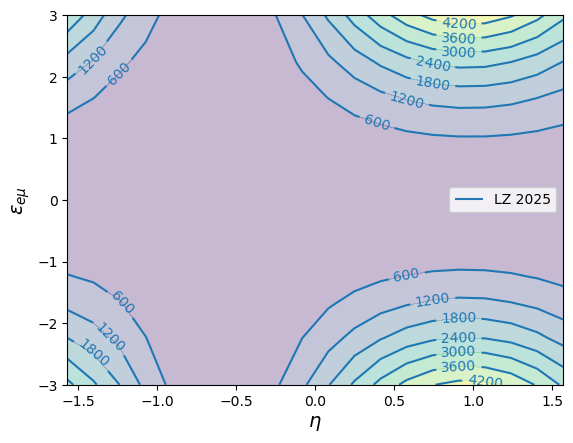

In [11]:
fig, ax = plt.subplots()

plt.contourf(etaGrid, epsGrid, N_LZ, alpha=0.3) 
contLZ = plt.contour(etaGrid, epsGrid, N_LZ, colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\eta$', size=14)

## Plot exclusion limit

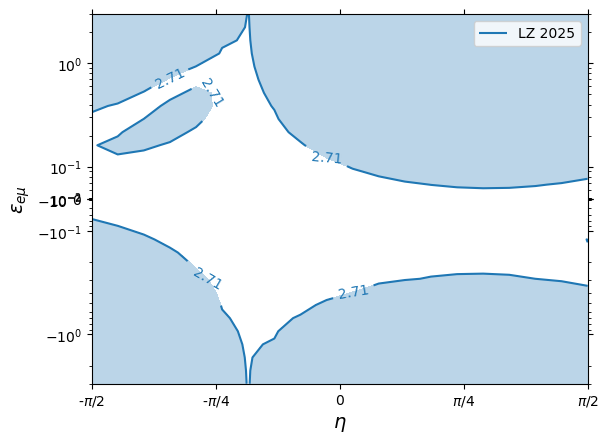

In [12]:
import matplotlib.ticker as tck



# # 2D 90% C.L. chi square
# q_crit = 4.61
# 1D 90% C.L. chi square
q_crit = 2.71

# Figure
fig, ax = plt.subplots()

plt.contourf(etaGrid, epsGrid, Tstat_LZ, levels=[q_crit, np.inf], colors='tab:blue', alpha=0.3) 
contLZ = plt.contour(etaGrid, epsGrid, Tstat_LZ, levels=[q_crit], colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

ax.set_yscale('symlog', linthresh=0.05, linscale=0.01)
# ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.set_xticks(np.pi*np.array([-1./2, -1./4, 0, 1./4, 1./2]), [r'-$\pi/2$', r'-$\pi/4$', '0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticks(np.outer(np.array([-0.01, -0.1, -1, 0.01, 0.1, 1]),np.array([2, 3, 4 , 5, 6, 7, 8, 9])).flatten(), minor=True)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_ylim(-3, 3)
plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\eta$', size=14)
plt.savefig("eps_emu_LL.png", bbox_inches='tight')




# Save data to file
#np.savetxt("events_LZ25.csv", np.array([epsGrid, etaGrid, N_LZ, Tstat_LZ]), header="2D data grids: eps, phi, nevents, test_stat", delimiter=",")
# np.save("events_LZ25.npy", np.array([epsGrid, etaGrid, N_LZ, Tstat_LZ]))